# HR Analytics - Employee Attrition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 4.5)
pd.options.display.max_columns = 500

## Load & Clean

In [2]:
df = pd.read_csv('HR_Analytics.csv')
df.shape

(1480, 38)

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]

YearsWithCurrManager    57
dtype: int64

In [4]:
df['EmpID'].duplicated().sum()

np.int64(10)

In [5]:
df = df.drop_duplicates(subset=['EmpID'], keep='first').reset_index(drop=True)
df.shape

(1470, 38)

Dropped `EmployeeCount`, `Over18`, `StandardHours` later - they're constant across all rows, no use for analysis.

## Attrition Rate

In [6]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Department / Gender / Salary / Role / Age
Already in the Power BI dashboard as charts - just tables here.

In [25]:
for col in ['Department', 'Gender', 'SalarySlab', 'JobRole', 'AgeGroup']:
    print((df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)).round(1).sort_values(ascending=False))
    print()

Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64

Gender
Male      17.0
Female    14.8
Name: Attrition, dtype: float64

SalarySlab
Upto 5k    21.8
10k-15k    13.5
5k-10k     11.1
15k+        3.8
Name: Attrition, dtype: float64

JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64

AgeGroup
18-25    35.8
26-35    19.1
55+      17.0
46-55    11.5
36-45     9.2
Name: Attrition, dtype: float64



## Overtime

In [8]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


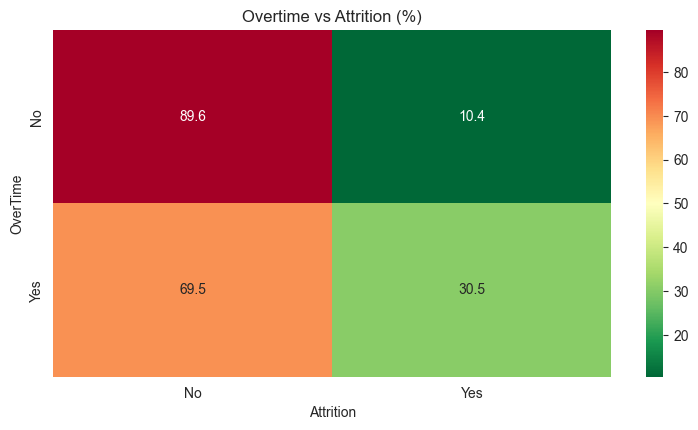

In [9]:
ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
sns.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn_r')
plt.title('Overtime vs Attrition (%)')
plt.show()

## Work Life Balance

In [10]:
(df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)).round(1)

WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: Attrition, dtype: float64

## Experience Bands
Grouping tenure into bands, different cut than the dashboard's continuous years chart.

In [11]:
df['ExperienceBand'] = pd.cut(df['TotalWorkingYears'], bins=[0,5,10,20,50],
                               labels=['0-5','6-10','11-20','20+'])
(df.groupby('ExperienceBand', observed=True)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)).round(1)

ExperienceBand
0-5      28.2
6-10     15.0
11-20    11.5
20+       7.7
Name: Attrition, dtype: float64

## Correlation with Attrition

In [29]:
d = df.copy()
d['Attrition_Num'] = (d['Attrition'] == 'Yes').astype(int)
d['OverTime_Num'] = (d['OverTime'] == 'Yes').astype(int)

corr = d.select_dtypes(include='number').corr()['Attrition_Num'].sort_values()
corr = corr.drop(['Attrition_Num', 'EmployeeCount', 'StandardHours'], errors='ignore')
corr

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsWithCurrManager       -0.162117
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
OverTime_Num                0.246118
Name: Attrition_Num, dtype: float64

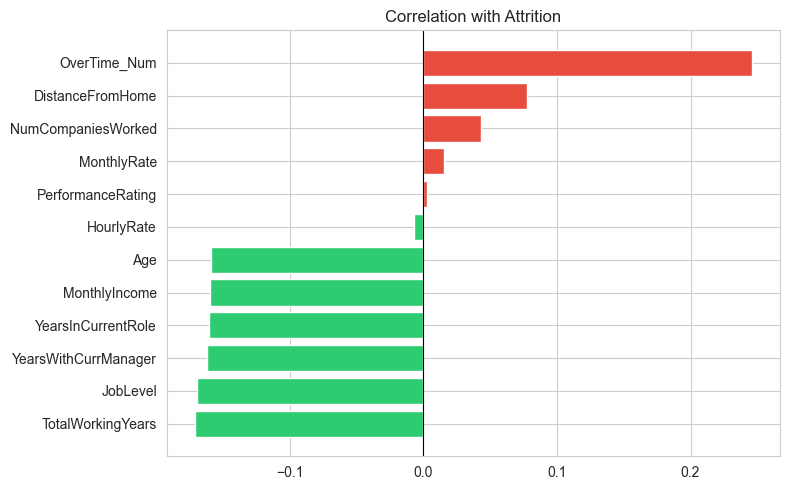

In [30]:
top = pd.concat([corr.head(6), corr.tail(6)])
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top.values]
plt.figure(figsize=(8,5))
plt.barh(top.index, top.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation with Attrition')
plt.tight_layout()
plt.show()

**Takeaways:** These correlations are individually weak-to-moderate, which is expected for human behavior data — no single factor drives attrition alone. That's exactly why I built a model afterward, to combine these weaker signals into a stronger combined prediction.

---
## Simple Attrition Prediction (Random Forest)
Just exploring if it's predictable from these attributes - not a production model, mainly a learning exercise.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [15]:
ml = df.copy()

ml['Attrition'] = ml['Attrition'].map({'Yes': 1, 'No': 0})
ml['Gender'] = ml['Gender'].map({'Male': 1, 'Female': 0})
ml['Over18'] = ml['Over18'].map({'Y': 1})
ml['OverTime'] = ml['OverTime'].map({'Yes': 1, 'No': 0})

for col, prefix in [('BusinessTravel', None), ('Department', 'Dept'),
                     ('EducationField', 'Edu'), ('JobRole', 'Role'), ('MaritalStatus', 'Status')]:
    ml = ml.join(pd.get_dummies(ml[col], prefix=prefix)).drop(col, axis=1)

ml = ml.map(lambda x: 1 if x is True else (0 if x is False else x))

ml = ml.drop(columns=['EmployeeNumber','EmpID','EmployeeCount','Over18','StandardHours',
                       'AgeGroup','SalarySlab','ExperienceBand'], errors='ignore')

ml['YearsWithCurrManager'] = ml['YearsWithCurrManager'].fillna(ml['YearsWithCurrManager'].median())
ml.shape

(1470, 51)

Dropped AgeGroup/SalarySlab - they're just binned copies of Age/MonthlyIncome, already in the model.

In [31]:
X, y = ml.drop('Attrition', axis=1), ml['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,  stratify=y)
y_train.value_counts(normalize=True)

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Only ~16% left, so a plain 0.5 cutoff will lean heavily toward predicting 'stayed'. Using class_weight and a lower threshold to compensate.

In [32]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, class_weight='balanced_subsample')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
probs = model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.35]:
    pred = (probs >= t).astype(int)
    print(f"threshold={t}  acc={accuracy_score(y_test,pred):.2f}  prec={precision_score(y_test,pred):.2f}  recall={recall_score(y_test,pred):.2f}  f1={f1_score(y_test,pred):.2f}")

threshold=0.5  acc=0.83  prec=1.00  recall=0.06  f1=0.11
threshold=0.35  acc=0.86  prec=0.72  recall=0.34  f1=0.46


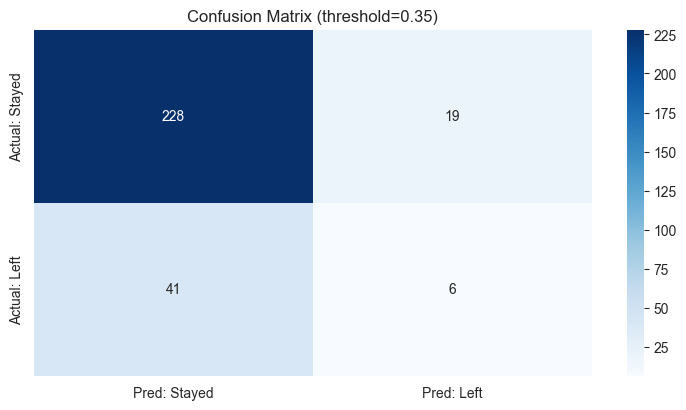

              precision    recall  f1-score   support

      Stayed       0.85      0.92      0.88       247
        Left       0.24      0.13      0.17        47

    accuracy                           0.80       294
   macro avg       0.54      0.53      0.53       294
weighted avg       0.75      0.80      0.77       294



In [33]:
y_pred = (probs >= 0.35).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Stayed','Pred: Left'], yticklabels=['Actual: Stayed','Actual: Left'])
plt.title('Confusion Matrix (threshold=0.35)')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))

In [20]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

MonthlyIncome        0.067580
Age                  0.056782
YearsAtCompany       0.051872
DistanceFromHome     0.051522
DailyRate            0.051378
MonthlyRate          0.050117
OverTime             0.049181
TotalWorkingYears    0.046564
HourlyRate           0.043101
StockOptionLevel     0.037650
dtype: float64

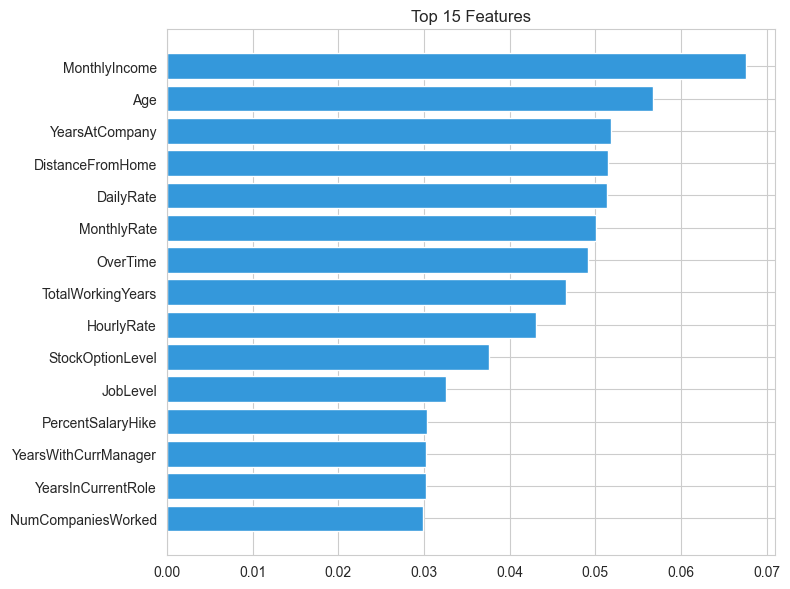

In [21]:
top15 = importances.head(15).sort_values()
plt.figure(figsize=(8,6))
plt.barh(top15.index, top15.values, color='#3498db')
plt.title('Top 15 Features')
plt.tight_layout()
plt.show()

## Model Comparison

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression baseline (needs scaling, unlike Random Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

rf_pred = (probs >= 0.35).astype(int)

comparison = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_test, log_pred),
        precision_score(y_test, log_pred),
        recall_score(y_test, log_pred),
        f1_score(y_test, log_pred)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score']).round(3)

comparison

,Logistic Regression,Random Forest
Accuracy,0.786,0.857
Precision,0.447,0.720
Recall,0.792,0.340
F1 Score,0.571,0.462


## Conclusion

Two classification models were evaluated for predicting employee attrition: Logistic Regression and Random Forest.

Although Random Forest achieved higher Accuracy (85.7%) and Precision (72.0%), Logistic Regression delivered substantially better Recall (79.2%) and F1-score (57.1%). Since employee attrition is an imbalanced classification problem where identifying employees at risk of leaving is more important than maximizing overall accuracy, Logistic Regression was selected as the final model.

This model provides greater value for HR by identifying a larger proportion of employees who are likely to leave, enabling more effective retention planning.

## Project Summary

- Cleaned the dataset by removing 10 duplicate records, dropping 3 constant columns, and imputing missing values using the median.
- Performed exploratory data analysis to identify key attrition drivers, including overtime, salary, work-life balance, tenure, and numerical feature correlations.
- Built an interactive Power BI dashboard to analyze attrition across departments, job roles, gender, age groups, and salary bands.
- Developed and compared Logistic Regression and Random Forest models for employee attrition prediction.
- Addressed class imbalance using class weighting and threshold tuning, and selected Logistic Regression based on superior Recall and F1-score.